In [2]:
# ---- Setup ----
import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.geom import SquareGrid, SE2, Obstacles
import models

Training State Autoencoder:   0%|          | 0/5000 [00:00<?, ?it/s]

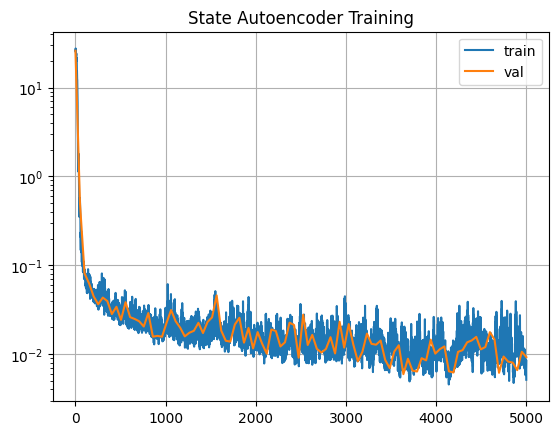

Test loss: 0.008543728850781918


In [3]:
# ---- Train State Autoencoder ----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Dataset
# ----------------------------
N = 120000

q_start_dataset = (torch.rand(N, 3) * 4 * np.pi) - 2 * np.pi
q_goal_dataset  = (torch.rand(N, 3) * 4 * np.pi) - 2 * np.pi

q_start_dataset = q_start_dataset.float()
q_goal_dataset  = q_goal_dataset.float()

# ----------------------------
# Split
# ----------------------------
p_train = 0.75
p_val   = 0.125
p_test  = 0.125
N_train = int(N * p_train)
N_val   = int(N * p_val)
N_test  = N - N_train - N_val

perm = torch.randperm(N)

train_idx = perm[:N_train]
val_idx   = perm[N_train:N_train + N_val]
test_idx  = perm[N_train + N_val:]

# ----------------------------
# Model
# ----------------------------
model = models.StateAutoEncoder(dof=3, latent_dim=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# Evaluation
# ----------------------------
def evaluate(indices):
    model.eval()

    q_start = q_start_dataset[indices].to(device)
    q_goal  = q_goal_dataset[indices].to(device)

    with torch.no_grad():
        q_start_rec, q_goal_rec, _ = model(q_start, q_goal)

        loss = (
            F.mse_loss(q_start_rec, q_start) +
            F.mse_loss(q_goal_rec, q_goal)
        )

    return loss.item()

# ----------------------------
# Training
# ----------------------------
batch_size = 64
epochs = 5000

train_history = []
val_history = []

for epoch in tqdm(range(epochs), desc="Training State Autoencoder"):

    model.train()

    idx = train_idx[torch.randint(0, len(train_idx), (batch_size,))]

    q_start = q_start_dataset[idx].to(device)
    q_goal  = q_goal_dataset[idx].to(device)

    opt.zero_grad()

    q_start_rec, q_goal_rec, _ = model(q_start, q_goal)

    loss = (
        F.mse_loss(q_start_rec, q_start) +
        F.mse_loss(q_goal_rec, q_goal)
    )

    loss.backward()
    opt.step()

    train_history.append(loss.item())

    if epoch % 50 == 0:
        val_history.append(evaluate(val_idx))

# ----------------------------
# Plot
# ----------------------------
plt.figure()
plt.plot(train_history, label="train")
plt.yscale("log")
plt.plot(
    np.linspace(0, len(train_history), len(val_history)),
    val_history,
    label="val"
)
plt.legend()
plt.grid()
plt.title("State Autoencoder Training")
plt.show()

print("Test loss:", evaluate(test_idx))

# ----------------------------
# Save
# ----------------------------
torch.save(model.state_dict(), "models/state_autoencoder.pt")
torch.save(model.encoder.state_dict(), "models/state_encoder.pt")

In [ ]:
# ---- Train Environment Autoencoder ----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = 12000


def build_sdf_from_obstacles(obstacles, grid_length=2.5, number_of_vox=128):
    grid = SquareGrid(
        data=np.zeros((number_of_vox, number_of_vox)),
        length=grid_length,
        origin=SE2.identity()
    )
    x = np.linspace(-grid_length/2, grid_length/2, number_of_vox)
    y = np.linspace(-grid_length/2, grid_length/2, number_of_vox)
    X, Y = np.meshgrid(x, y)
    for i in range(len(obstacles.r)):
        dist_to_center = np.sqrt((X - obstacles.x[i])**2 + (Y - obstacles.y[i])**2)
        grid.data[dist_to_center <= obstacles.r[i]] = 1.0
    sdf = grid.derive_sdf_from_voxels().data
    return torch.from_numpy(sdf).float().unsqueeze(0)

def sample_obstacles(n_obs=3):
    xy = np.random.uniform(-1.0, 1.0, size=(n_obs, 2))
    r  = np.random.uniform(0.05, 0.2, size=(n_obs,))
    return xy, r

def generate_env_dataset(N, seed=42):
    np.random.seed(seed)
    sdf_list = []
    for _ in tqdm(range(N), desc="Generating SDF dataset"):
        xy, r = sample_obstacles(3)
        obstacles = Obstacles(x=xy[:, 0], y=xy[:, 1], r=r)
        sdf_list.append(build_sdf_from_obstacles(obstacles))
    return torch.stack(sdf_list)

# ----------------------------
# Cache: load or generate
# ----------------------------
DATA_PATH = "data/sdf_dataset.pt"
os.makedirs("data", exist_ok=True)

if os.path.exists(DATA_PATH):
    sdf_dataset = torch.load(DATA_PATH, weights_only=True)
    print(f"sdf_dataset geladen: {sdf_dataset.shape}")
else:
    sdf_dataset = generate_env_dataset(N, seed=42)
    torch.save(sdf_dataset, DATA_PATH)
    print(f"sdf_dataset erzeugt und gespeichert: {sdf_dataset.shape}")

# ----------------------------
# Split
# ----------------------------
perm = torch.randperm(N)
N_train = int(0.75 * N)
N_val   = int(0.125 * N)
train_idx = perm[:N_train]
val_idx   = perm[N_train:N_train + N_val]
test_idx  = perm[N_train + N_val:]

# ----------------------------
# Model
# ----------------------------
model = models.EnvAutoEncoder(latent_dim=64).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(indices):
    model.eval()
    sdf = sdf_dataset[indices].to(device)
    with torch.no_grad():
        sdf_rec, _ = model(sdf)
        loss = F.mse_loss(sdf_rec, sdf)
    return loss.item()

# ----------------------------
# Training
# ----------------------------
batch_size = 64
epochs = 5000

train_history = []
val_history = []

for epoch in tqdm(range(epochs), desc="Training Env Autoencoder"):

    model.train()
    idx = train_idx[torch.randint(0, len(train_idx), (batch_size,))]
    sdf = sdf_dataset[idx].to(device)

    opt.zero_grad()
    sdf_rec, z = model(sdf)
    loss = F.mse_loss(sdf_rec, sdf)
    loss.backward()
    opt.step()

    train_history.append(loss.item())
    if epoch % 50 == 0:
        val_history.append(evaluate(val_idx))

# ----------------------------
# Plot
# ----------------------------
plt.figure()
plt.plot(train_history, label="train")
plt.yscale("log")
plt.plot(
    np.linspace(0, len(train_history), len(val_history)),
    val_history,
    label="val"
)
plt.legend()
plt.grid()
plt.title("Environment Autoencoder Training")
plt.show()

print("Test loss:", evaluate(test_idx))

# ----------------------------
# Save
# ----------------------------
torch.save(model.state_dict(), "models/env_autoencoder.pt")
torch.save(model.encoder.state_dict(), "models/env_encoder.pt")